=== DATA SETUP ===
Loaded lifted states shape: (1000, 38)
Total time steps: 1000 | Total lifted dimensions: 38

=== KOOPMAN TRAINING (RIDGE EDMD) ===
Koopman operator matrix K shape: (38, 38)
Training 1-Step Global RMSE: 0.183438

=== LIVE INFERENCE DEMO ===
Input Live Vector Shape : (1, 38)
Predicted Next Step Shape: (1, 38)
--------------------------------------------------



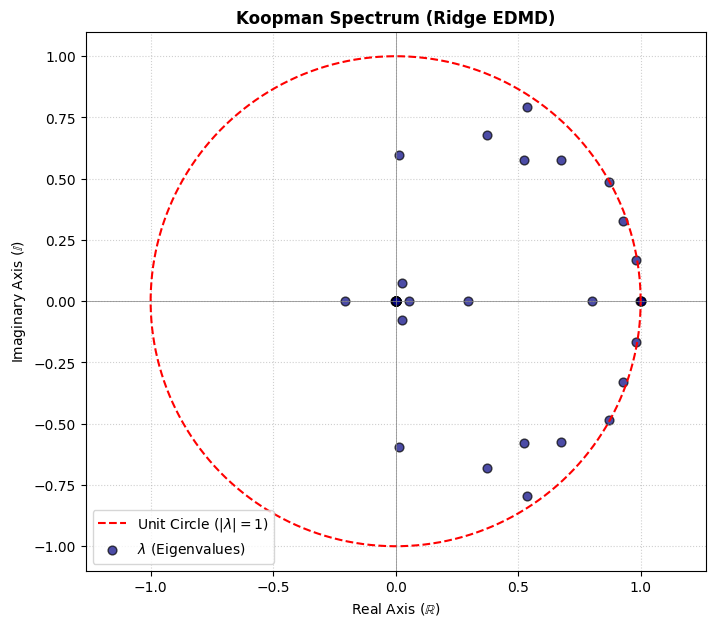

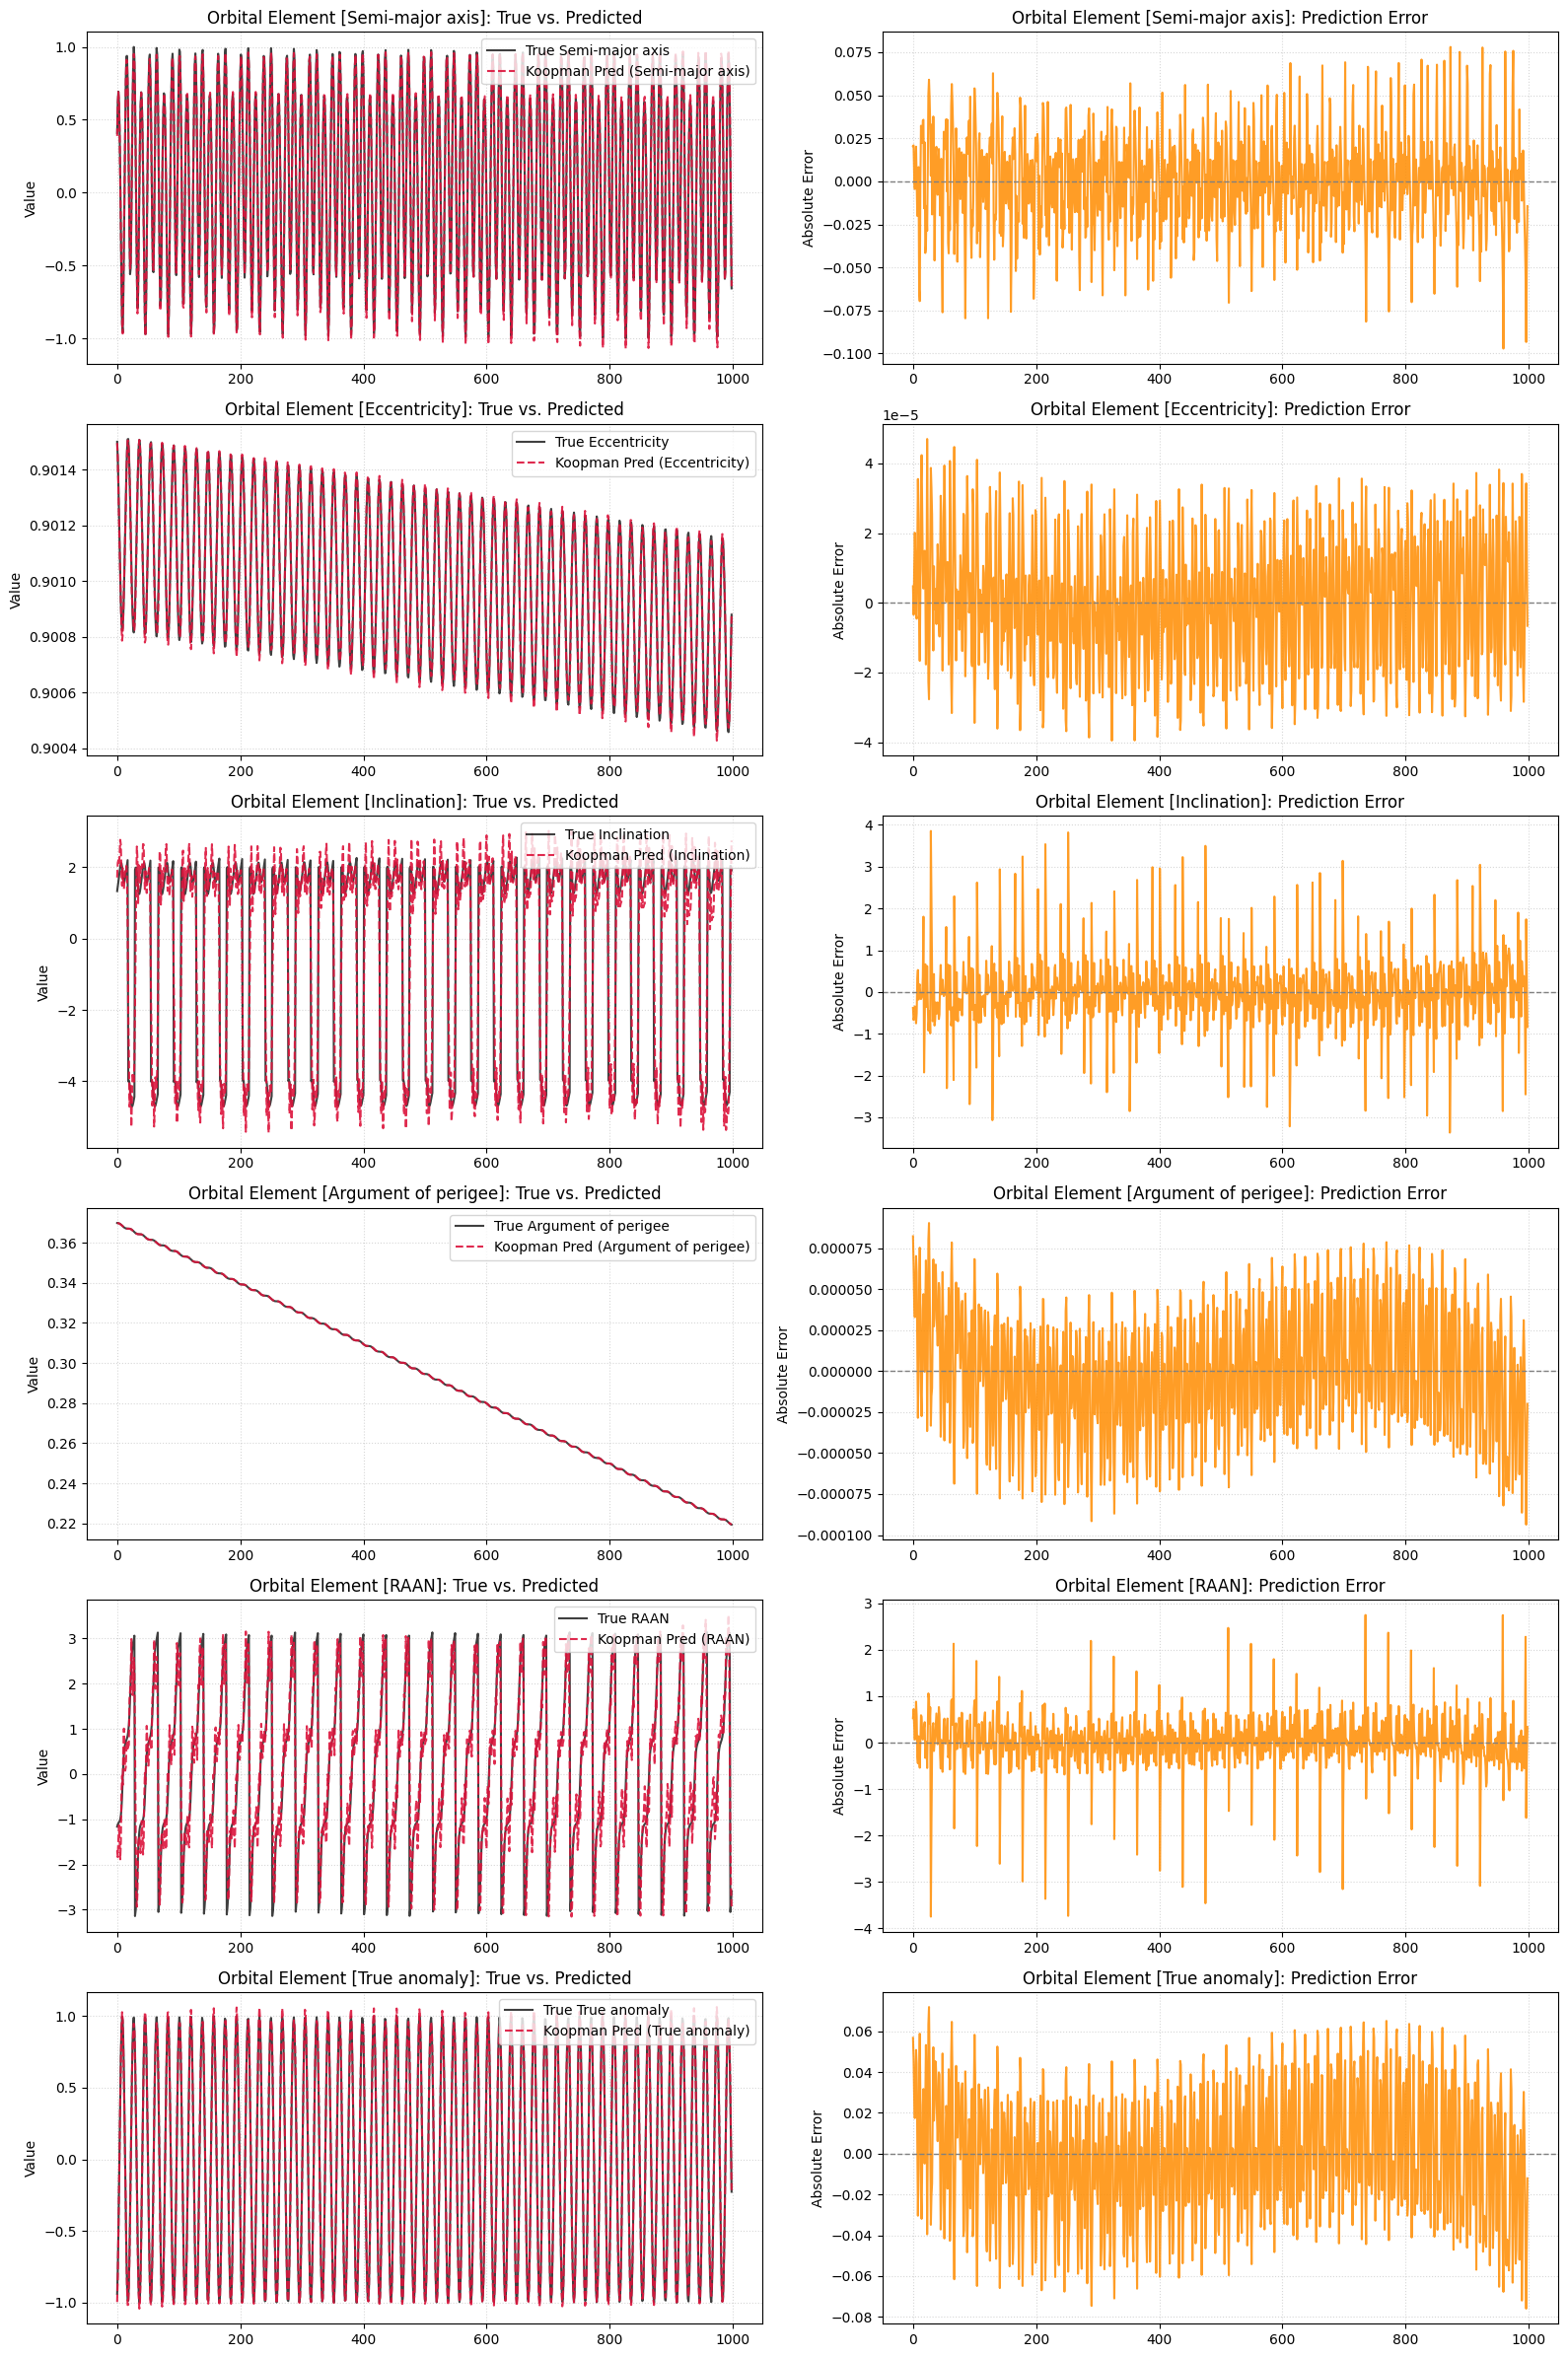

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# ==============================================================================
# 1. DATA LOADING & PREPARATION (TRAINING PHASE)
# ==============================================================================
try:
    df = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError:
    raise FileNotFoundError(
        "Could not find 'lifted_orbit_data.csv'. Please make sure the file is "
        "in your current VS Code working directory."
    )

Z = df.values  # These are your 'lifted' dictionary states \psi(x)
n_samples, n_dim = Z.shape

# Shift data to align Before (Z1 at time k) and After (Z2 at time k+1)
Z1 = Z[:-1]
Z2 = Z[1:]

print(f"=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples} | Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. TRAIN KOOPMAN OPERATOR (RIDGE EDMD FOR OPTIMAL 1-STEP MAPPING)
# ==============================================================================
# alpha=1e-4 adds a small penalty to keep the weights of your features stable
model = Ridge(alpha=1e-4, fit_intercept=False)
model.fit(Z1, Z2)

# Extract the Koopman Operator matrix K
K = model.coef_

print(f"=== KOOPMAN TRAINING (RIDGE EDMD) ===")
print(f"Koopman operator matrix K shape: {K.shape}")


# ==============================================================================
# 3. EVALUATE 1-STEP ACCURACY ON LIFTED TRAINING DATA
# ==============================================================================
# Predict Z2 using our learned K matrix
Z2_pred = Z1 @ K.T

# Calculate Global Error Metrics
error = Z2 - Z2_pred
rmse = np.sqrt(np.mean(error**2))

print(f"Training 1-Step Global RMSE: {rmse:.6f}\n")


# ==============================================================================
# 4. LIVE INFERENCE PHASE DEMO
# ==============================================================================
print(f"=== LIVE INFERENCE DEMO ===")
sample_live_vector = Z1[0:1, :]  # Taking the first row as an example input

# Predict the state at t + delta_t
next_step_prediction = sample_live_vector @ K.T

print(f"Input Live Vector Shape : {sample_live_vector.shape}")
print(f"Predicted Next Step Shape: {next_step_prediction.shape}")
print("-" * 50 + "\n")


# ==============================================================================
# 5. DIAGNOSTIC DASHBOARD VISUALIZATION
# ==============================================================================
# --- Figure 1: Koopman Spectrum Analysis ---
eigvals, _ = np.linalg.eig(K)

plt.figure(figsize=(8, 7))
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'r--', linewidth=1.5, label='Unit Circle ($|\lambda|=1$)')
plt.scatter(eigvals.real, eigvals.imag, color='navy', alpha=0.7, edgecolors='k', s=40, label='$\lambda$ (Eigenvalues)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("Koopman Spectrum (Ridge EDMD)", fontsize=12, fontweight='bold')
plt.xlabel("Real Axis ($\mathbb{R}$)")
plt.ylabel("Imaginary Axis ($\mathbb{I}$)")
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.show()

# --- Figure 2: Dynamic Tracking & Error for Orbital Elements ---
# Maps specific index offsets (1 through 7) to their respective Keplerian element names
target_features = list(range(2, 8)) 
feature_names = ["Semi-major axis", "Eccentricity", "Inclination", "Argument of perigee", "RAAN", "True anomaly"]

fig, axes = plt.subplots(len(target_features), 2, figsize=(16, 4 * len(target_features)))

for i, feature_idx in enumerate(target_features):
    name = feature_names[i]
    true_lifted = Z2[:, feature_idx]
    pred_lifted = Z2_pred[:, feature_idx]
    error_lifted = true_lifted - pred_lifted
    
    # Left Column: Lifted Space Tracking
    ax_comp = axes[i, 0]
    ax_comp.plot(true_lifted, label=f"True {name}", color='black', alpha=0.75)
    ax_comp.plot(pred_lifted, '--', label=f"Koopman Pred ({name})", color='crimson', alpha=0.9)
    ax_comp.set_title(f"Orbital Element [{name}]: True vs. Predicted")
    ax_comp.set_ylabel("Value")
    ax_comp.grid(True, linestyle=':', alpha=0.5)
    ax_comp.legend(loc='upper right')
    
    # Right Column: Lifted Residuals
    ax_err = axes[i, 1]
    ax_err.plot(error_lifted, color='darkorange', alpha=0.85)
    ax_err.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax_err.set_title(f"Orbital Element [{name}]: Prediction Error")
    ax_err.set_ylabel("Absolute Error")
    ax_err.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()